# Plan-and-Execute

복잡한 작업을 단계별로 계획하고 실행하며, 중간 결과에 따라 계획을 수정하는 Plan-and-Execute 패턴을 배운다.

In [1]:
import operator
from typing import Annotated, TypedDict, Union

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field


load_dotenv()

MODEL_NAME = "gemini-3.6-flash"

### Plan-and-Execute란

Plan-and-Execute는 먼저 전체 계획을 세운 뒤 각 단계를 실행하는 패턴이다. 실행 결과를 검토하고 필요에 따라 남은 계획을 수정할 수 있다.

| 구분 | ReAct | Plan-and-Execute |
|---|---|---|
| 계획 범위 | 매 순간 다음 행동 결정 | 전체 계획을 먼저 수립 |
| 장점 | 단순하고 빠름 | 복잡한 목표와 제약 조건 처리에 유리 |
| 단점 | 전체 흐름을 놓칠 수 있음 | 계획과 재계획 비용 발생 |
| 적합한 작업 | 단일 조회, 간단한 질의 | 조사, 비교, 일정 설계, 보고서 작성 |

```text
입력 → Planner → Executor → Replanner → Executor → ... → 최종 응답
```

Planner는 실행할 단계 목록을 만들고, Executor는 현재 계획의 첫 단계를 수행한다. Replanner는 실행 결과가 충분한지 판단하여 종료하거나 남은 계획을 교체한다.

### State와 출력 모델 정의

Plan-and-Execute에서는 현재 계획뿐 아니라 완료된 단계와 최종 응답도 추적해야 한다. Planner와 Replanner의 출력은 Pydantic 모델로 정의한다.

| 필드 | 타입 | 역할 |
|---|---|---|
| `input` | `str` | 사용자의 원래 요청 |
| `plan` | `list[str]` | 앞으로 실행할 단계 |
| `past_steps` | `list[tuple[str, str]]` | `(실행한 단계, 실행 결과)` 튜플의 목록 |
| `response` | `str` | 사용자에게 전달할 최종 응답 |

`past_steps`는 실행 이력을 보존해야 하므로 `operator.add` reducer로 누적한다. `plan`은 Replanner가 남은 계획 전체를 바꿀 수 있도록 reducer 없이 덮어쓴다.

In [3]:

llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

class PlanExecuteState(TypedDict):
    input: str
    plan: list[str]
    past_steps: Annotated[list[tuple[str, str]], operator.add]
    response: str

class Plan(BaseModel):
    """앞으로 수행할 계획"""

    steps: list[str] = Field(description="순서대로 수행할 단계")


class Response(BaseModel):
    """사용자에게 전달할 최종 응답"""

    response: str = Field(description="검색 결과를 반영한 최종 여행 계획")


class ReplanDecision(BaseModel):
    """Replanner가 선택한 다음 결정"""

    decision: Union[Plan, Response]

### Planner

Planner는 사용자 요청을 구체적이고 실행 가능한 검색 단계로 나눈다. 한 단계에는 하나의 조사 목표만 포함한다.

In [4]:
planner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 여행 요청을 실행 계획으로 만드는 Planner입니다.
각 단계는 Google Search로 조사할 수 있는 구체적인 작업이어야 합니다.
교통, 숙박, 관광지 운영 정보, 식당, 예산 검증처럼 서로 다른 조사 목표를 나누세요.
실행하지 않은 결과를 미리 판단하지 마세요.
계획은 최대 5단계로 작성하세요.""",
    ),
    ("human", "{input}"),
])

planner = planner_prompt | llm.with_structured_output(Plan)


def plan_step(state: PlanExecuteState):
    """사용자 요청을 바탕으로 초기 계획을 생성한다."""
    result = planner.invoke({"input": state["input"]})
    return {"plan": result.steps}

### Executor

Executor는 현재 계획의 첫 단계를 수행한다. Google Search가 연결된 Gemini를 사용해 최신 여행 정보를 조사하고 출처 URL과 함께 결과를 정리한다.

In [5]:
search_llm = llm.bind_tools([{"google_search": {}}])

def execute_step(state: PlanExecuteState):
    """현재 계획의 첫 단계를 Google Search로 실행한다."""
    current_step = state["plan"][0]

    past_context = ""
    if state.get("past_steps"):
        past_context = "\n\n지금까지 확인한 결과:\n" + "\n".join(
            f"- {step}: {result}"
            for step, result in state["past_steps"]
        )

    task = f"""다음 여행 조사 단계를 수행하세요.

현재 단계:
{current_step}

요구사항:
- Google Search로 최신 정보를 확인하세요.
- 가격, 운영시간, 이동시간을 구체적으로 정리하세요.
- 확인한 정보의 출처 URL을 포함하세요.
- 현재 단계에 필요한 내용만 간결하게 작성하세요.
{past_context}"""

    result = search_llm.invoke(task)

    return {"past_steps": [(current_step, result.text)]}

### Replanner

Replanner는 원래 요청과 지금까지의 검색 결과를 비교한다. 정보가 부족하면 완료된 단계를 제외한 새 계획을 만들고, 조건을 판단할 수 있으면 최종 여행 계획을 작성한다.

Replanner는 매 실행 이후 `past_steps`를 확인한다.

| 상황 | 판단 |
|---|---|
| 필요한 정보가 부족함 | 추가 조사 단계를 계획에 포함 |
| 검색 결과가 조건에 맞지 않음 | 대안을 조사하도록 계획 수정 |
| 모든 조건을 판단할 수 있음 | 최종 응답 생성 |

`Union[A, B]`는 값의 타입으로 A 또는 B 중 하나를 허용한다는 뜻이다. 예를 들어 `Union[Plan, Response]`로 선언하면 `Plan` 객체나 `Response` 객체 중 하나를 저장할 수 있다.

Replanner는 한 번의 호출에서 **남은 계획을 반환하거나 최종 응답을 반환한다**. 두 결과가 동시에 필요한 것은 아니므로 `ReplanDecision`의 `decision` 필드를 `Union[Plan, Response]`로 정의해 둘 중 하나만 선택하게 한다. 반면 그래프의 State에서는 실행할 `plan`과 종료 시 사용할 `response`의 역할이 다르므로 별도 필드로 관리한다.

완료된 단계를 새 계획에서 제거하지 않으면 같은 검색이 반복될 수 있다. 프롬프트에서 완료된 단계의 반복을 금지하고 `recursion_limit`으로 무한 반복을 방지한다. `recursion_limit`은 한 번의 그래프 실행에서 허용하는 최대 노드 실행 횟수다. 같은 노드를 반복해서 실행하는 경우도 매번 횟수에 포함된다. 아래 실행 코드의 `recursion_limit=20`은 노드 실행을 최대 20번까지 허용한다는 뜻이며, 한도를 초과하면 `GraphRecursionError`가 발생한다.

In [6]:
replanner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 여행 계획의 진행 상황을 검토하는 Replanner입니다.

원래 요청과 완료한 조사 결과를 보고 다음 중 하나를 선택하세요.
- 필요한 정보가 부족하면 완료한 단계를 반복하지 말고 남은 Plan을 반환합니다.
- 조건을 충족하는 여행 계획을 작성할 수 있으면 Response를 반환합니다.
- 검색 결과에서 제약 조건을 만족하지 못한 항목이 발견되면 대안을 조사하는 단계를 추가합니다.
- 최종 응답에는 일정, 예상 비용, 이동 방법, 주의사항, 출처를 포함합니다.""",
    ),
    (
        "human",
        """목표:
{input}

현재 계획:
{plan}

완료한 단계:
{past_steps}""",
    ),
])

replanner = replanner_prompt | llm.with_structured_output(ReplanDecision)



def replan_step(state: PlanExecuteState):
    """검색 결과를 바탕으로 계획을 수정하거나 최종 응답을 생성한다."""
    result = replanner.invoke({
        "input": state["input"],
        "plan": "\n".join(
            f"- {step}"
            for step in state["plan"]
        ),
        "past_steps": "\n".join(
            f"- {step}: {step_result}"
            for step, step_result in state["past_steps"]
        ),
    })

    if isinstance(result.decision, Response):
        return {"response": result.decision.response}

    return {"plan": result.decision.steps}


def should_continue(state: PlanExecuteState):
    """최종 응답이 있으면 종료하고, 없으면 다음 단계를 실행한다."""
    return "end" if state.get("response") else "continue"

### 그래프 구성

Planner가 초기 계획을 만들고, Executor와 Replanner가 최종 응답이 생성될 때까지 반복한다.

In [7]:
graph_builder = StateGraph(PlanExecuteState)

graph_builder.add_node("planner", plan_step)
graph_builder.add_node("executor", execute_step)
graph_builder.add_node("replanner", replan_step)

graph_builder.add_edge(START, "planner")
graph_builder.add_edge("planner", "executor")
graph_builder.add_edge("executor", "replanner")
graph_builder.add_conditional_edges(
    "replanner",
    should_continue,
    {
        "continue": "executor",
        "end": END,
    },
)

graph = graph_builder.compile()

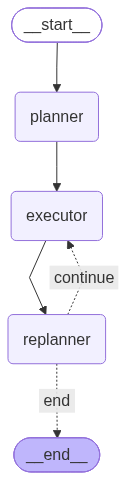

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))

### 실행

여러 조건을 함께 고려해야 하는 여행 계획을 요청한다. 검색 결과에서 휴무, 매진, 예산 초과 같은 문제가 확인되면 Replanner가 대안을 조사하도록 계획을 수정한다.

In [ ]:
inputs = {
    "input": (
        "다음 주 토요일에 서울에서 출발하는 강릉 당일치기 여행 계획을 만들어줘. "
        "대중교통을 중심으로 이동하고, 관광지 2곳 이상과 현지 식당을 포함해줘. "
        "1인 총예산은 15만 원 이하야. 운영시간과 예상 비용도 알려줘."
    )
}

config = {"recursion_limit": 20}

state_history = []

for mode, event in graph.stream(
    inputs,
    config=config,
    stream_mode=["updates", "values"],
):
    if mode == "values":
        state_history.append(event)
        continue

    for node_name, value in event.items():
        if node_name == "planner":
            print("\n[초기 계획]")
            for step in value["plan"]:
                print(f"- {step}")

        elif node_name == "executor":
            step, result = value["past_steps"][-1]
            print(f"\n[실행] {step}")
            print(result)

        elif node_name == "replanner" and value.get("plan"):
            print("\n[수정된 계획]")
            for step in value["plan"]:
                print(f"- {step}")

        elif node_name == "replanner" and value.get("response"):
            print("\n[최종 응답]")
            print(value["response"])

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.



[초기 계획]
- 서울-강릉 왕복 KTX 열차 시간표 및 요금 조사
- 강릉 주요 관광지 2곳 이상(예: 안목해변, 오죽헌 등)의 위치, 운영시간, 입장료 조사
- 강릉 현지 추천 식당 및 카페의 대표 메뉴 가격과 영업시간 조사
- 강릉 시내 대중교통(버스, 택시) 이동 동선 및 예상 교통비 조사
- 관광지, 식당, 교통비를 합산하여 15만 원 예산 범위 내 당일치기 일정표 및 예산 검증

[실행] 서울-강릉 왕복 KTX 열차 시간표 및 요금 조사
서울-강릉 구간 KTX(KTX-이음) 왕복 여행을 위한 최신 시간표, 요금, 소요시간 정보입니다.

---

### 1. KTX 열차 요금 (편도 기준)
* **서울역 ↔ 강릉역**
  * **일반실:** 성인 27,600원 / 어린이 13,800원 / 경로 19,300원
  * **우등실(특실):** 성인 33,100원 (일반실 운임 + 우등 추가 요금)
  * **입석/자유석:** 성인 26,200원
* **청량리역 ↔ 강릉역:** 일반실 성인 기준 26,000원

> **왕복 예상 비용 (서울역 기준, 성인 일반실):** 1인당 **55,200원**

---

### 2. 이동시간 및 운행 횟수
* **소요시간:** 평균 **1시간 50분 ~ 2시간 10분** (정차역 수에 따라 상이)
* **운행 횟수:** 편도 기준 하루 약 14~20회 운행 (주말/평일에 따라 차등 운행)

---

### 3. 주요 운행시간표 (첫차/막차 기준)

* **[가는 편] 서울역 ➔ 강릉역**
  * **첫차:** 05:06 출발 ➔ 07:03 도착 (소요시간 1시간 57분)
  * **막차:** 22:14 출발 ➔ 00:05(+1) 도착 (소요시간 1시간 51분)
  * *배차 간격: 약 1시간 ~ 1시간 30분 간격 운행*

* **[오는 편] 강릉역 ➔ 서울역**
  * **첫차:** 05:20 출발 ➔ 07:23 도착 (소요시간 2시간 3분)
  * **막차:** 22:27 출발 ➔ 00:25(+1) 도착 (소요시간 

In [ ]:
print("\n[State 흐름]")

for index, state in enumerate(state_history):
    print(f"\n[State {index}]")

    for key, value in state.items():
        if key == "past_steps":
            print("past_steps:")
            for step, _ in value:
                print(f"  - {step}")
        elif key == "response":
            print("response:", bool(value))
            print(value)
        else:
            print(f"{key}:", value)


[State 흐름]

[State 0]
input: 다음 주 토요일에 서울에서 출발하는 강릉 당일치기 여행 계획을 만들어줘. 대중교통을 중심으로 이동하고, 관광지 2곳 이상과 현지 식당을 포함해줘. 1인 총예산은 15만 원 이하야. 운영시간과 예상 비용도 알려줘.
past_steps:

[State 1]
input: 다음 주 토요일에 서울에서 출발하는 강릉 당일치기 여행 계획을 만들어줘. 대중교통을 중심으로 이동하고, 관광지 2곳 이상과 현지 식당을 포함해줘. 1인 총예산은 15만 원 이하야. 운영시간과 예상 비용도 알려줘.
plan: ['서울-강릉 왕복 KTX 열차 시간표 및 요금 조사', '강릉 주요 관광지 2곳 이상(예: 안목해변, 오죽헌 등)의 위치, 운영시간, 입장료 조사', '강릉 현지 추천 식당 및 카페의 대표 메뉴 가격과 영업시간 조사', '강릉 시내 대중교통(버스, 택시) 이동 동선 및 예상 교통비 조사', '관광지, 식당, 교통비를 합산하여 15만 원 예산 범위 내 당일치기 일정표 및 예산 검증']
past_steps:

[State 2]
input: 다음 주 토요일에 서울에서 출발하는 강릉 당일치기 여행 계획을 만들어줘. 대중교통을 중심으로 이동하고, 관광지 2곳 이상과 현지 식당을 포함해줘. 1인 총예산은 15만 원 이하야. 운영시간과 예상 비용도 알려줘.
plan: ['서울-강릉 왕복 KTX 열차 시간표 및 요금 조사', '강릉 주요 관광지 2곳 이상(예: 안목해변, 오죽헌 등)의 위치, 운영시간, 입장료 조사', '강릉 현지 추천 식당 및 카페의 대표 메뉴 가격과 영업시간 조사', '강릉 시내 대중교통(버스, 택시) 이동 동선 및 예상 교통비 조사', '관광지, 식당, 교통비를 합산하여 15만 원 예산 범위 내 당일치기 일정표 및 예산 검증']
past_steps:
  - 서울-강릉 왕복 KTX 열차 시간표 및 요금 조사

[State 3]
input: 다음 주 토요일에 서울에서 출발하는 강릉 당일치기 여행 계획을 만들어줘. 대중교통

### 실습 문제

2026년 생성형 AI 트렌드를 조사하는 Plan-and-Execute 그래프를 처음부터 구현해보자.

사용자 요청:

> 2026년 생성형 AI 트렌드를 조사하고, 주요 트렌드 5개를 선정해 근거와 함께 요약 보고서를 작성해줘.


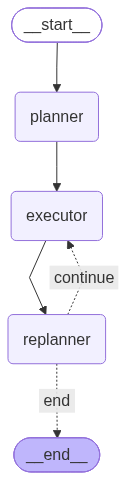

In [7]:

research_request = (
    "2026년 생성형 AI 트렌드를 조사하고, "
    "주요 트렌드 5개를 선정해 근거와 함께 요약 보고서를 작성해줘. "
    "각 트렌드의 특징과 예상 영향을 정리하고 출처를 포함해줘."
)

class PlanExecuteState(TypedDict):
    input: str
    plan: list[str]
    past_steps: Annotated[list[tuple[str, str]], operator.add]
    response: str

class Plan(BaseModel):
    """앞으로 수행할 계획"""

    steps: list[str] = Field(description="순서대로 수행할 단계")


class Response(BaseModel):
    """사용자에게 전달할 최종 응답"""

    response: str = Field(description="검색 결과를 반영한 최종 여행 계획")


class ReplanDecision(BaseModel):
    """Replanner가 선택한 다음 결정"""

    decision: Union[Plan, Response]


planner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 2026년 생성형 AI의 트렌드를 조사하는 Planner입니다.
각 단계는 Google Search로 조사할 수 있는 구체적인 작업이어야 합니다.
주요 트렌드 5개를 선정해 근거와 함께 요약 보고서를 작성해야 합니다.
각 트렌드의 특징과 예상 영향을 정리하고 출처를 포함해야합니다
실행하지 않은 결과를 미리 판단하지 마세요.
계획은 최대 5단계로 작성하세요.""",
    ),
    ("human", "{input}"),
])

planner = planner_prompt | llm.with_structured_output(Plan)


def plan_step(state: PlanExecuteState):
    """사용자 요청을 바탕으로 초기 계획을 생성한다."""
    result = planner.invoke({"input": state["input"]})
    return {"plan": result.steps}

search_llm = llm.bind_tools([{"google_search": {}}])

def execute_step(state: PlanExecuteState):
    """현재 계획의 첫 단계를 Google Search로 실행한다."""
    current_step = state["plan"][0]

    past_context = ""
    if state.get("past_steps"):
        past_context = "\n\n지금까지 확인한 결과:\n" + "\n".join(
            f"- {step}: {result}"
            for step, result in state["past_steps"]
        )

    task = f"""다음 생성형 AI 트렌드 조사 단계를 수행하세요.

현재 단계:
{current_step}

요구사항:
- Google Search로 최신 정보를 확인하세요.
- 2026년 생성형 AI 트렌드와 직접 관련된 내용만 정리하세요.
- 근거가 되는 기사, 보고서, 기업 발표, 연구 자료의 출처 URL을 포함하세요.
- 현재 단계에 필요한 내용만 간결하게 작성하세요.
{past_context}"""

    result = search_llm.invoke(task)

    return {"past_steps": [(current_step, result.text)]}

replanner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 2026년 생성형 AI 트렌드를 조사의 진행 상황을 검토하는 Replanner입니다.

원래 요청과 완료한 조사 결과를 보고 다음 중 하나를 선택하세요.
- 필요한 정보가 부족하면 완료한 단계를 반복하지 말고 남은 Plan을 반환합니다.
- 조건을 충족하는 2026년 생성형 AI 트렌드를 요약 보고서를 작성할 수 있으면 Response를 반환합니다.
- 검색 결과에서 제약 조건을 만족하지 못한 항목이 발견되면 대안을 조사하는 단계를 추가합니다.
- 최종 응답에는 주요 트렌드 5개, 각 트렌드의 특징, 예상 영향, 근거, 출처 URL을 포함합니다.""",
    ),
    (
        "human",
        """목표:
{input}

현재 계획:
{plan}

완료한 단계:
{past_steps}""",
    ),
])

replanner = replanner_prompt | llm.with_structured_output(ReplanDecision)



def replan_step(state: PlanExecuteState):
    """검색 결과를 바탕으로 계획을 수정하거나 최종 응답을 생성한다."""
    result = replanner.invoke({
        "input": state["input"],
        "plan": "\n".join(
            f"- {step}"
            for step in state["plan"]
        ),
        "past_steps": "\n".join(
            f"- {step}: {step_result}"
            for step, step_result in state["past_steps"]
        ),
    })

    if isinstance(result.decision, Response):
        return {"response": result.decision.response}

    return {"plan": result.decision.steps}


def should_continue(state: PlanExecuteState):
    """최종 응답이 있으면 종료하고, 없으면 다음 단계를 실행한다."""
    return "end" if state.get("response") else "continue"

graph_builder = StateGraph(PlanExecuteState)

graph_builder.add_node("planner", plan_step)
graph_builder.add_node("executor", execute_step)
graph_builder.add_node("replanner", replan_step)

graph_builder.add_edge(START, "planner")
graph_builder.add_edge("planner", "executor")
graph_builder.add_edge("executor", "replanner")
graph_builder.add_conditional_edges(
    "replanner",
    should_continue,
    {
        "continue": "executor",
        "end": END,
    },
)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
inputs = {
    "input": research_request
}

config = {"recursion_limit": 20}

state_history = []

for mode, event in graph.stream(
    inputs,
    config=config,
    stream_mode=["updates", "values"],
):
    if mode == "values":
        state_history.append(event)
        continue

    for node_name, value in event.items():
        if node_name == "planner":
            print("\n[초기 계획]")
            for step in value["plan"]:
                print(f"- {step}")

        elif node_name == "executor":
            step, result = value["past_steps"][-1]
            print(f"\n[실행] {step}")
            print(result)

        elif node_name == "replanner" and value.get("plan"):
            print("\n[수정된 계획]")
            for step in value["plan"]:
                print(f"- {step}")

        elif node_name == "replanner" and value.get("response"):
            print("\n[최종 응답]")
            print(value["response"])

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.



[초기 계획]
- Gartner, Forrester, IDC 등 주요 기관의 2026년 생성형 AI 기술 및 산업 전망 보고서를 Google Search로 조사
- 조사된 자료를 바탕으로 2026년을 주도할 주요 생성형 AI 트렌드 5개를 선정하고 각 트렌드의 선정 근거 수집
- 선정된 5개 트렌드별 핵심 특징과 산업 및 사회에 미칠 예상 영향 정리
- 각 트렌드 관련 데이터 및 주장에 대한 정확한 출처 정보 수집 및 검증
- 구체적 근거, 특징, 예상 영향 및 출처를 포함한 2026년 생성형 AI 트렌드 최종 요약 보고서 작성

[실행] Gartner, Forrester, IDC 등 주요 기관의 2026년 생성형 AI 기술 및 산업 전망 보고서를 Google Search로 조사
Gartner, Forrester, IDC 등 주요 IT 시장조사기관에서 발표한 **2026년 생성형 AI 기술 및 산업 전망** 분석 결과입니다. 

2026년 생성형 AI 트렌드는 단순 기술 실험과 거품(Hype) 단계를 넘어, **자율형 AI 에이전트(Agentic AI)의 실질적 업무 적용, ROI(투자 대비 수익) 검증, AI 거버넌스 및 보안 강화**로 핵심 축이 이동하고 있습니다.

---

### 주요 기관별 2026년 생성형 AI 트렌드 및 전망

#### 1. Gartner (가트너)
* **Agentic AI(AI 에이전트)의 기업 애플리케이션 전면 배치**
  * 2026년 말까지 전체 기업 애플리케이션의 **40%**에 특정 작업을 수행하는 AI 에이전트가 통합될 전망 (이전 5% 미만 수준에서 급증).
* **AI 플랫폼 및 모델 시장 폭발적 성장**
  * 2026년 글로벌 AI 플랫폼 및 모델 시장은 **63% 성장**할 것으로 예상되며, 기업들이 AI 사용 방식과 범위를 효율적으로 관리하도록 돕는 플랫폼 솔루션이 시장을 주도할 것으로 분석.
* **비용 초과 및 보안 리스크 부각**
  * 미흡한 아키텍처 및 운영 노하우 부재로 인해 2028년까지 Ge

In [13]:
## 강사님 풀이

research_request = (
    "2026년 생성형 AI 트렌드를 조사하고, "
    "주요 트렌드 5개를 선정해 근거와 함께 요약 보고서를 작성해줘. "
    "각 트렌드의 특징과 예상 영향을 정리하고 출처를 포함해줘."
)

llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

# 전체 State
class State(TypedDict):
    # 사용자의 입력
    input: str
    # planning, replanning에서 변경하는 계획. reducer X
    plans: list[str]
    # execute를 통해 실행된 결과. reducer가 있어야 함.
    results: Annotated[list, operator.add]
    # 최종 응답
    response: str

# planning에서 사용하는 응답 형식
class Plan(BaseModel):
    plans: list[str]

class Response(BaseModel):
    response: str

class ReplanDecision(BaseModel):
    decision: Union[Plan, Response]

def planning(state: State):
    user_input = state['input']
    research_planner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 조사 계획을 수립하는 Planner입니다.
사용자의 요청에서 조사 목표, 제약 조건과 결과물 요구사항을 파악하세요.
목표를 달성하는 데 필요한 조사만 구체적이고 실행 가능한 단계로 계획하세요.
각 단계는 하나의 명확한 조사 목표를 가지며 Google Search로 수행할 수 있어야 합니다.
앞 단계에서 확인할 정보가 필요하면 그 의존 관계가 순서에 드러나야 합니다.
아직 조사하지 않은 내용을 사실처럼 가정하지 마세요.
최종 보고서 작성은 계획에 포함하지 말고, 조사 단계만 최대 5개로 반환하세요.""",
    ),
    (
        "human",
        """조사 요청:
{input}""",
    ),
])
    chain = research_planner_prompt | llm.with_structured_output(Plan)
    # 추가 프롬프트가 필요함.
    response = chain.invoke({'input' : user_input})
    return {
        'plans': response.plans
    }

def execute(state: State):
    # input을 llm에게 전달할지 말지는 고민해보고 정함.
    # 여러 가지 들을 test하고 가장 좋은걸 고르는게 맞습니다.
    current_plan = state['plans'][0]

    research_executor_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 계획에서 지정된 조사 단계 하나를 수행하는 Researcher입니다.
원래 요청과 이전 조사 결과를 문맥으로 사용하되 현재 단계의 목표에만 집중하세요.
Google Search로 근거를 찾고, 신뢰할 수 있는 최신 출처를 우선하세요.
확인된 사실과 해석을 구분하고, 자료 사이에 충돌이 있으면 숨기지 말고 밝히세요.
핵심 조사 결과와 함께 자료 제목, 발행 주체, 발행 시점과 URL을 제시하세요.
근거를 찾지 못한 내용은 추측하지 말고 확인하지 못했다고 명시하세요.""",
    ),
    (
        "human",
        """조사 요청:
{input}

현재 단계:
{current_step}

이전 조사 결과:
{findings}""",
    ),
])
    ReAct_agent = llm.bind_tools([{"google_search": {}}])

    # state['results'] = [[plan1, text1], [plan2, text2], [plan3, text3]]
    # result = ""
    # for plan, text in state['results']:
    #     result += f"{plan} - {text}\n"

    research_executor = research_executor_prompt | ReAct_agent
    response = research_executor.invoke({
        'input': state['input'],
        'current_step': state['plans'][0],
        'findings': "\n".join([f"{plan} - {text}" for plan, text in state['results']])
    })

    return {'results': [[current_plan, response.text]]}
    

def replanning(state: State):
    results = state['results']
    research_replanner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 조사 진행 상황을 판단하는 Replanner입니다.
원래 요청의 조사 목표, 제약 조건과 결과물 요구사항을 기준으로 조사 결과를 평가하세요.
핵심 정보가 없거나 근거가 약하거나 출처가 충돌하면 ResearchPlan을 반환하세요.
ResearchPlan에는 이미 완료한 단계를 제외하고 다음에 필요한 조사 단계만 포함하세요.
현재 계획에 단계가 남아 있어도 이미 충분한 경우에는 불필요한 조사를 계속하지 마세요.
요청을 충족할 근거가 충분하면 ResearchReport를 반환하세요.
보고서는 조사 결과에 있는 정보만 사용하고, 불확실성과 한계를 명시하며,
사용자가 요청한 형식과 출처 표기 요구를 따르세요.""",
    ),
    (
        "human",
        """원래 조사 요청:
{input}

현재 계획:
{plan}

조사 결과:
{findings}""",
    ),
])

    # 지금까지의 실행 결과를 가지고
    # 계속 계획을 진행할지, 응답으로 만들지 -> Router스러운 역할.
    llm_with_plan_or_response_output = research_replanner_prompt | llm.with_structured_output(ReplanDecision)
    response = llm_with_plan_or_response_output.invoke({
        'input': state['input'],
        'plan': "\n".join(state['plans']),
        'findings': "\n".join([f"{plan} - {text}" for plan, text in state['results']])
    })

    # if response가 Response야.
    if isinstance(response.decision, Response):
        return {'response' : response.decision.response}
    # if response가 Plan이야.
    return {'plans' : response.decision.plans}
    

def should_continue(state: State):
    if state.get('response'):
        return 'end'
    return 'continue'
        

builder = StateGraph(State)

builder.add_node('planning', planning)
builder.add_node('execute', execute)
builder.add_node('replanning', replanning)

builder.add_edge(START, 'planning')
builder.add_edge('planning', 'execute')
builder.add_edge('execute', 'replanning')

builder.add_conditional_edges('replanning',
                              should_continue,
                              {
                                'continue'  : 'execute',
                                'end'  : END
                              })


graph = builder.compile()

response = graph.invoke({'input' : research_request})

### 추가 실습: Replanner 없는 Plan-and-Execute

Replanner는 Plan-and-Execute의 필수 구성요소가 아니다. 초기 계획을 수정할 필요가 없다면 Planner가 만든 계획을 그대로 실행할 수 있다.

앞에서 구현한 여행 계획 그래프에서 Replanner를 제거하고, Planner가 처음 만든 계획을 순서대로 모두 실행하도록 수정해보자.

> 힌트: Executor가 현재 단계를 실행한 뒤 `{"plan": state["plan"][1:]}`을 반환하면 완료한 단계를 계획에서 제거할 수 있다. `plan`이 비었는지를 기준으로 Executor와 최종 응답 생성 노드 사이를 분기할 수 있다.

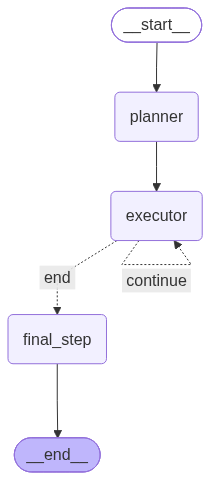

In [11]:

research_request = (
    "2026년 생성형 AI 트렌드를 조사하고, "
    "주요 트렌드 5개를 선정해 근거와 함께 요약 보고서를 작성해줘. "
    "각 트렌드의 특징과 예상 영향을 정리하고 출처를 포함해줘."
)

class PlanExecuteState(TypedDict):
    input: str
    plan: list[str]
    past_steps: Annotated[list[tuple[str, str]], operator.add]
    response: str

class Plan(BaseModel):
    """앞으로 수행할 계획"""

    steps: list[str] = Field(description="순서대로 수행할 단계")


class Response(BaseModel):
    """사용자에게 전달할 최종 응답"""

    response: str = Field(description="검색 결과를 반영한 최종 여행 계획")



planner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 2026년 생성형 AI의 트렌드를 조사하는 Planner입니다.
각 단계는 Google Search로 조사할 수 있는 구체적인 작업이어야 합니다.
주요 트렌드 5개를 선정해 근거와 함께 요약 보고서를 작성해야 합니다.
각 트렌드의 특징과 예상 영향을 정리하고 출처를 포함해야합니다
실행하지 않은 결과를 미리 판단하지 마세요.
계획은 최대 5단계로 작성하세요.""",
    ),
    ("human", "{input}"),
])

planner = planner_prompt | llm.with_structured_output(Plan)


def plan_step(state: PlanExecuteState):
    """사용자 요청을 바탕으로 초기 계획을 생성한다."""
    result = planner.invoke({"input": state["input"]})
    return {"plan": result.steps}



search_llm = llm.bind_tools([{"google_search": {}}])

def execute_step(state: PlanExecuteState):
    """현재 계획의 첫 단계를 Google Search로 실행한다."""
    current_step = state["plan"][0]

    past_context = ""
    if state.get("past_steps"):
        past_context = "\n\n지금까지 확인한 결과:\n" + "\n".join(
            f"- {step}: {result}"
            for step, result in state["past_steps"]
        )

    task = f"""다음 생성형 AI 트렌드 조사 단계를 수행하세요.

현재 단계:
{current_step}

요구사항:
- Google Search로 최신 정보를 확인하세요.
- 2026년 생성형 AI 트렌드와 직접 관련된 내용만 정리하세요.
- 근거가 되는 기사, 보고서, 기업 발표, 연구 자료의 출처 URL을 포함하세요.
- 현재 단계에 필요한 내용만 간결하게 작성하세요.
{past_context}"""

    result = search_llm.invoke(task)

    return {"past_steps": [(current_step, result.text)],
            "plan": state["plan"][1:],
            }


final_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 2026년 생성형 AI 트렌드 조사 결과를 바탕으로 최종 요약 보고서를 작성하는 전문가입니다.
최종 응답에는 주요 트렌드 5개, 각 트렌드의 특징, 예상 영향, 근거, 출처 URL을 포함하세요.""",
    ),
    (
        "human",
        """원래 요청:
{input}

완료한 조사 결과:
{past_steps}

위 내용을 바탕으로 최종 보고서를 작성하세요.""",
    ),
])

finalizer = final_prompt | llm.with_structured_output(Response)


def final_step(state: PlanExecuteState):
    result = finalizer.invoke({
        "input": state["input"],
        "past_steps": "\n".join(
            f"- {step}: {step_result}"
            for step, step_result in state["past_steps"]
        ),
    })

    return {"response": result.response}


def should_continue(state: PlanExecuteState):
    """plan이 남아 있으면 계속 실행하고, 비었으면 최종 응답을 만든다."""
    return "continue" if state.get("plan") else "end"

graph_builder = StateGraph(PlanExecuteState)

graph_builder.add_node("planner", plan_step)
graph_builder.add_node("executor", execute_step)
graph_builder.add_node("final_step", final_step)

graph_builder.add_edge(START, "planner")
graph_builder.add_edge("planner", "executor")
graph_builder.add_conditional_edges(
    "executor",
    should_continue,
    {
        "continue": "executor",
        "end": "final_step",
    },
)

graph_builder.add_edge("final_step", END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
inputs = {
    "input": research_request
}

config = {"recursion_limit": 20}

state_history = []

for mode, event in graph.stream(
    inputs,
    config=config,
    stream_mode=["updates", "values"],
):
    if mode == "values":
        state_history.append(event)
        continue

    for node_name, value in event.items():
        if node_name == "planner":
            print("\n[초기 계획]")
            for step in value["plan"]:
                print(f"- {step}")

        elif node_name == "executor":
            step, result = value["past_steps"][-1]
            print(f"\n[실행] {step}")
            print(result)

        elif node_name == "final_step":
            print("\n[최종 응답]")
            print(value["response"])


[초기 계획]
- Google Search를 통해 2026년 생성형 AI 시장 전망 및 핵심 기술 트렌드 관련 자료 검색 및 수집하기
- 수집된 자료를 분석하여 가장 언급량이 많고 중요한 2026년 생성형 AI 주요 트렌드 5가지 선정 및 선정 근거 정리하기
- 선정된 5가지 트렌드 각각의 핵심 특징과 향후 산업 및 사회에 미칠 예상 영향 분석하기
- 각 트렌드별 관련 출처 정보를 확인하고 분류하여 데이터의 신뢰성 확보하기
- 수집된 근거, 특징, 예상 영향, 출처를 종합하여 2026년 생성형 AI 트렌드 요약 보고서 작성하기

[실행] Google Search를 통해 2026년 생성형 AI 시장 전망 및 핵심 기술 트렌드 관련 자료 검색 및 수집하기
**[현재 단계: 2026년 생성형 AI 시장 전망 및 핵심 기술 트렌드 자료 수집 결과]**

Google Search를 통해 글로벌 시장조사기관(Gartner, IDC 등) 및 주요 기술 리포트를 수집한 2026년 생성형 AI 시장 전망 및 핵심 기술 트렌드 요약입니다.

---

### 1. 2026년 생성형 AI 시장 전망 (Market Outlook)

* **AI 모델 및 플랫폼 지출 급증**: Gartner 전망에 따르면, 2026년 글로벌 AI 모델 및 플랫폼 최종 사용자 지출은 **642억 5,000만 달러(전년 대비 63.4% 증가)**에 달할 예정입니다. 
  * 생성형 AI 기초 모델(Foundation GenAI) 지출: **233억 5,600만 달러 (+104.2%)**
  * 도메인 특화 모델(DSLM) 및 전문화 모델 지출: **49억 1,000만 달러 (+210.0%)**
* **AI 인프라 및 추론(Inference) 위주 전환**: 
  * IDC에 따르면 글로벌 AI 인프라 지출은 **4,870억 달러(전년 대비 53% 증가)** 수준에 도달할 것으로 예상됩니다.
  * Gartner는 2026년 글로벌 AI 최적화 IaaS 지출이 **422억 7,600만 달러(+96.4%)

In [ ]:
## 강사님 풀이

# State 재활용
# class State:
#     pass


# 위에서 사용한 plan 재활
# def plan():
#     pass


def execute_no_replan(state: PlanExecuteState):
    """현재 계획의 첫 단계를 Google Search로 실행한다."""
    current_step = state["plan"][0]

    past_context = ""
    if state.get("past_steps"):
        past_context = "\n\n지금까지 확인한 결과:\n" + "\n".join(
            f"- {step}: {result}"
            for step, result in state["past_steps"]
        )

    task = f"""다음 여행 조사 단계를 수행하세요.

현재 단계:
{current_step}

요구사항:
- Google Search로 최신 정보를 확인하세요.
- 가격, 운영시간, 이동시간을 구체적으로 정리하세요.
- 확인한 정보의 출처 URL을 포함하세요.
- 현재 단계에 필요한 내용만 간결하게 작성하세요.
{past_context}"""

    # ReAct Agent
    result = search_llm.invoke(task)

    return {
        "past_steps": [(current_step, result.text)],
        'plan' : state["plan"][1:] # plan을 slicing해서 0번째 index의 값을 없앰.
        }


def should_continue(state: PlanExecuteState):
    # 실행할 plan이 있으면 continue
    if state['plan']:
        return 'continue'
    # 없으면 finalize
    return 'finalize'

def finalize(state: PlanExecuteState):
    prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """다음 조사결과를 배탕으로 최종 응답을 만들어라.
- 최종 응답에는 일정, 예상 비용, 이동 방법, 주의사항, 출처를 포함합니다.""",
    ),
    ("human", "{input} 조사 결과 : {results}"),
])
    response = (prompt | llm).invoke({
        'input' : state['input'],
        'results' : "\n".join(
            f"- {step}: {step_result}"
            for step, step_result in state["past_steps"]
        )
    })

    return { 'response' : response.text}

builder = StateGraph(PlanExecuteState)
builder.add_node('plan', plan_step)
builder.add_node('execute', execute_no_replan)
builder.add_node('finalize', finalize)

builder.add_edge(START, 'plan')
builder.add_edge('plan', 'execute')
builder.add_conditional_edges('execute',
                              should_continue,
                              {
                                  'continue' : 'execute',
                                  'finalize' : 'finalize'
                              })

builder.add_edge('finalize', END)
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))



In [ ]:
inputs = {
    "input": (
        "다음 주 토요일에 서울에서 출발하는 강릉 당일치기 여행 계획을 만들어줘. "
        "대중교통을 중심으로 이동하고, 관광지 2곳 이상과 현지 식당을 포함해줘. "
        "1인 총예산은 15만 원 이하야. 운영시간과 예상 비용도 알려줘."
    )
}

config = {"recursion_limit": 20}

state_history = []

for mode, event in graph.stream(
    inputs,
    config=config,
    stream_mode=["updates", "values"],
):
    print('--node--')
    if mode == "values":
        state_history.append(event)
        continue

    for node_name, value in event.items():
        if node_name == "plan":
            print("\n[초기 계획]")
            for step in value["plan"]:
                print(f"- {step}")

        elif node_name == "execute":
            step, result = value["past_steps"][-1]
            print(f"\n[실행] {step}")
            print(result)


        elif node_name == "finalize" and value.get("response"):
            print("\n[최종 응답]")
            print(value["response"])